In [ ]:
!pip install tensorflow

In [4]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [17]:
import numpy as np
import pandas as pd

def load_fd004_dataset(train_path, test_path, rul_path):
    train = pd.read_csv(train_path, sep=r'\s+', header=None)
    test = pd.read_csv(test_path, sep=r'\s+', header=None)
    rul_test = pd.read_csv(rul_path, header=None)

    columns = (
        ['engine_id', 'cycle'] +
        [f'op_setting_{i}' for i in range(1,4)] +
        [f'sensor_{i}' for i in range(1,22)]
    )

    train.columns = columns
    test.columns = columns
    rul_test.columns = ['RUL']

    return train, test, rul_test


# 🔹 Load data
train, test, rul_test = load_fd004_dataset(
    'train_FD004.txt',
    'test_FD004.txt',
    'RUL_FD004.txt'
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (61249, 26)
Test shape: (41214, 26)


In [18]:
def compute_rul(df, cap_value=125):
    max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycle.columns = ['engine_id', 'cycle_max']

    df = df.merge(max_cycle, on='engine_id')
    df['RUL'] = df['cycle_max'] - df['cycle']

    # Apply capping (optional)
    if cap_value is not None:
        df['RUL'] = df['RUL'].clip(upper=cap_value)

    return df


train = compute_rul(train, cap_value=125)

print(train[['engine_id','cycle','cycle_max','RUL']].head())

   engine_id  cycle  cycle_max  RUL
0          1      1        321  125
1          1      2        321  125
2          1      3        321  125
3          1      4        321  125
4          1      5        321  125


In [19]:
# ==========================
# SPLIT BY ENGINE ID
# ==========================

from sklearn.model_selection import train_test_split

engine_ids = train['engine_id'].unique()

train_engine_ids, val_engine_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = train[train['engine_id'].isin(train_engine_ids)]
val_df = train[train['engine_id'].isin(val_engine_ids)]

print("Train engines:", len(train_engine_ids))
print("Validation engines:", len(val_engine_ids))

Train engines: 199
Validation engines: 50


In [21]:
def get_feature_columns(df):
    exclude_cols = ['engine_id', 'cycle', 'cycle_max', 'RUL']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    return feature_cols


feature_cols = get_feature_columns(train)

print("Number of features:", len(feature_cols))

Number of features: 24


In [22]:
WINDOW_SIZE = 30

def build_sequences(dataframe, feature_cols, window_size=30):
    X, y = [], []

    for engine_id in dataframe['engine_id'].unique():
        engine_data = dataframe[dataframe['engine_id'] == engine_id]
        engine_data = engine_data.sort_values('cycle')

        features = engine_data[feature_cols].values
        labels = engine_data['RUL'].values

        for i in range(len(engine_data) - window_size):
            X.append(features[i:i+window_size])
            y.append(labels[i+window_size])

    return np.array(X), np.array(y)


# 🔹 Build sequences
X_train, y_train = build_sequences(train_df, feature_cols, WINDOW_SIZE)
X_val, y_val     = build_sequences(val_df, feature_cols, WINDOW_SIZE)

In [23]:
# from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(
#     X_sequences,
#     y_sequences,
#     test_size=0.2,
#     random_state=42
# )

# print("Train shape:", X_train.shape)
# print("Validation shape:", X_val.shape)

In [24]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_val):
    scaler = StandardScaler()

    # Flatten for scaling
    X_train_2d = X_train.reshape(-1, X_train.shape[-1])
    X_val_2d   = X_val.reshape(-1, X_val.shape[-1])

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler


# 🔹 Apply scaling
X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow as tf

# ✅ Custom accuracy
def rul_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    error = tf.abs(y_true - y_pred)
    return tf.reduce_mean(tf.cast(error <= 20, tf.float32))

# ✅ Asymmetric + weighted loss
def asymmetric_weighted_mae(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    error = y_pred - y_true
    abs_error = tf.abs(error)

    weight = 1.0 / (y_true + 1.0)
    over_penalty = tf.where(error > 0, 2.0, 1.0)

    return tf.reduce_mean(weight * over_penalty * abs_error)


# 🔥 DYNAMIC INPUT SHAPE (IMPORTANT)
def build_model(input_shape):
    model = Sequential([

        Input(shape=input_shape),

        LSTM(
            64,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(1e-4),
            recurrent_regularizer=regularizers.l2(1e-4)
        ),
        Dropout(0.4),

        LSTM(
            32,
            return_sequences=False,
            kernel_regularizer=regularizers.l2(1e-4),
            recurrent_regularizer=regularizers.l2(1e-4)
        ),
        Dropout(0.4),

        Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        BatchNormalization(),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0007),
        loss=asymmetric_weighted_mae,
        metrics=['mae', rul_accuracy]
    )

    return model


# 🔥 Automatically get shape from data
input_shape = (X_train.shape[1], X_train.shape[2])

model = build_model(input_shape)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 30, 64)              │          22,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,417 (142.25 KB)

 Trainable params: 36,353 (142.00 KB)

 Non-trainable params: 64 (256.00 B)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - loss: 0.9873 - mae: 88.1616 - rul_accuracy: 0.0975 - val_loss: 0.9744 - val_mae: 86.1940 - val_rul_accuracy: 0.1044
Epoch 2/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - loss: 0.9659 - mae: 86.8477 - rul_accuracy: 0.1034 - val_loss: 0.9498 - val_mae: 83.7856 - val_rul_accuracy: 0.1158
Epoch 3/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - loss: 0.9359 - mae: 84.7443 - rul_accuracy: 0.1132 - val_loss: 0.9069 - val_mae: 81.1713 - val_rul_accuracy: 0.1268
Epoch 4/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - loss: 0.8877 - mae: 80.8691 - rul_accuracy: 0.1309 - val_loss: 0.8432 - val_mae: 75.0122 - val_rul_accuracy: 0.1555
Epoch 5/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.8213 - mae: 74.7894 - rul_accuracy: 0.1548 - val_loss: 0.7715 - val_mae: 68.9714 - val_rul_accuracy: 0.1653
Epoch 6/80
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - loss: 0.7390 - mae: 66.7244 - rul_accuracy: 0.1693 - val_loss: 0.6479 - val_mae: 56.

In [27]:
from sklearn.metrics import mean_absolute_error

val_pred = model.predict(X_val_scaled).flatten()

val_mae = mean_absolute_error(y_val, val_pred)

print("Validation MAE (Absolute RUL):", val_mae)

327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
Validation MAE (Absolute RUL): 24.75369644165039


In [28]:
# =================================
# EXTRACT FAILURE TIMES (FD004 TRAIN)
# =================================

failure_times = train.groupby('engine_id')['cycle'].max().values

print("Number of engines:", len(failure_times))
print("Min failure cycle:", failure_times.min())
print("Max failure cycle:", failure_times.max())
print("Average failure cycle:", failure_times.mean())

Number of engines: 249
Min failure cycle: 128
Max failure cycle: 543
Average failure cycle: 245.97991967871485


In [29]:
def build_test_sequences(test_df, feature_cols, window_size=30):
    X_test_sequences = []

    for engine_id in test_df['engine_id'].unique():
        engine_data = test_df[test_df['engine_id'] == engine_id]
        engine_data = engine_data.sort_values('cycle')

        features = engine_data[feature_cols].values

        if len(features) >= window_size:
            seq = features[-window_size:]
        else:
            padding = np.zeros((window_size - len(features), features.shape[1]))
            seq = np.vstack((padding, features))

        X_test_sequences.append(seq)

    return np.array(X_test_sequences)


# 🔹 Build test sequences
X_test_sequences = build_test_sequences(test, feature_cols, WINDOW_SIZE)

In [30]:
def scale_test_data(X_test_sequences, scaler):
    X_test_2d = X_test_sequences.reshape(-1, X_test_sequences.shape[-1])
    X_test_scaled = scaler.transform(X_test_2d).reshape(X_test_sequences.shape)
    return X_test_scaled


# 🔹 Apply scaling
X_test_scaled = scale_test_data(X_test_sequences, scaler)

In [31]:
test_pred = model.predict(X_test_scaled).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [32]:
true_rul = rul_test['RUL'].values

test_mae = mean_absolute_error(true_rul, test_pred)

print("FD004 TEST MAE (Absolute):", test_mae)

FD004 TEST MAE (Absolute): 29.9027099609375


In [33]:
print("Min predicted:", test_pred.min())
print("Max predicted:", test_pred.max())
print("Min true:", true_rul.min())
print("Max true:", true_rul.max())

Min predicted: -3.5977468
Max predicted: 154.91684
Min true: 6
Max true: 195


In [34]:
train.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'cycle_max', 'RUL'],
      dtype='object')

In [35]:
train[['op_setting_1','op_setting_2','op_setting_3']].describe()

,op_setting_1,op_setting_2,op_setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [36]:
from scipy.stats import weibull_min

# Fit Weibull (force location = 0)
beta, loc, eta = weibull_min.fit(failure_times, floc=0)

print("Weibull shape (beta):", beta)
print("Weibull scale (eta):", eta)

Weibull shape (beta): 3.4705072888272763
Weibull scale (eta): 272.87012729778576


In [37]:
import numpy as np

def pdf(t, beta, eta):
    return (beta/eta) * (t/eta)**(beta-1) * np.exp(-(t/eta)**beta)

def cdf(t, beta, eta):
    return 1 - np.exp(-(t/eta)**beta)

def survival(t, beta, eta):
    return np.exp(-(t/eta)**beta)

def hazard(t, beta, eta):
    return pdf(t, beta, eta) / survival(t, beta, eta)

In [38]:
# =================================
# SELECT TEST ENGINE
# =================================

engine_id = 1  # change to any test engine

engine_data = test[test['engine_id'] == engine_id].sort_values('cycle')

current_cycle = engine_data['cycle'].max()

print("Current observed cycle:", current_cycle)

# =================================
# PREPARE LAST WINDOW FOR ENGINE
# =================================

features = engine_data[feature_cols].values

if len(features) >= WINDOW_SIZE:
    seq = features[-WINDOW_SIZE:]
else:
    padding = np.zeros((WINDOW_SIZE - len(features), features.shape[1]))
    seq = np.vstack((padding, features))

seq = seq.reshape(1, WINDOW_SIZE, len(feature_cols))

# Scale
seq_2d = seq.reshape(-1, seq.shape[-1])
seq_scaled = scaler.transform(seq_2d).reshape(seq.shape)

# Predict
predicted_rul = model.predict(seq_scaled).flatten()[0]
predicted_failure_cycle = current_cycle + predicted_rul

# =================================
# GET TRUE RUL FROM NASA FILE
# =================================

true_rul = rul_test.iloc[engine_id - 1]['RUL']
true_failure_cycle = current_cycle + true_rul

# =================================
# PRINT RESULTS
# =================================

print("Engine ID:", engine_id)
print("Current observed cycle:", current_cycle)

print("True RUL:", true_rul)
print("Predicted RUL:", round(predicted_rul, 2))

print("True failure cycle:", current_cycle + true_rul)
print("Predicted failure cycle:", round(predicted_failure_cycle, 2))

print("Absolute Error:", abs(true_rul - predicted_rul))

Current observed cycle: 230
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Engine ID: 1
Current observed cycle: 230
True RUL: 22
Predicted RUL: 26.66
True failure cycle: 252
Predicted failure cycle: 256.66
Absolute Error: 4.655086517333984


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
ENGINE RELIABILITY ANALYSIS
Engine ID: 173
Current observed cycle: 151

--- RUL PREDICTION ---
True RUL: 8
Predicted RUL: -0.17
Absolute Error: 8.17

--- FAILURE CYCLE ESTIMATION ---
True failure cycle: 159
Predicted failure cycle: 150.83

--- MAINTENANCE DECISION ---
⚠ Maintenance Recommended


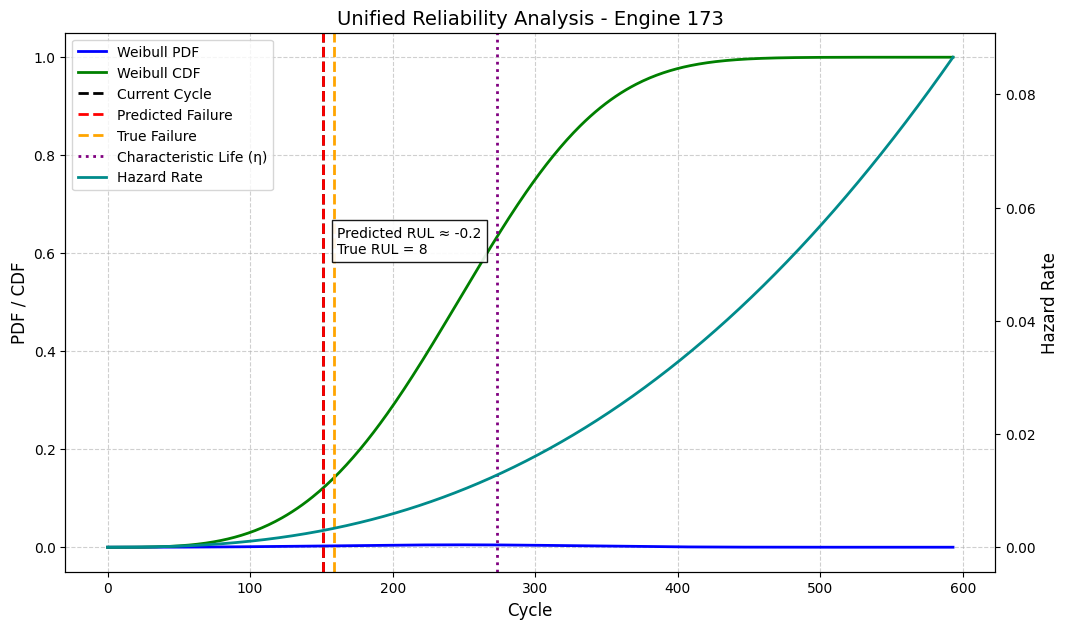

In [68]:
# =========================================================
# ENGINE RELIABILITY ANALYSIS (Prediction + Weibull Plot)
# =========================================================

engine_id = 173   # <-- Change engine here

# ===============================
# GET ENGINE DATA
# ===============================

engine_data = test[test['engine_id'] == engine_id].sort_values('cycle')
current_cycle = engine_data['cycle'].max()

# ===============================
# PREPARE MODEL INPUT
# ===============================

features = engine_data[feature_cols].values

if len(features) >= WINDOW_SIZE:
    seq = features[-WINDOW_SIZE:]
else:
    padding = np.zeros((WINDOW_SIZE - len(features), features.shape[1]))
    seq = np.vstack((padding, features))

seq = seq.reshape(1, WINDOW_SIZE, len(feature_cols))

# Scale
seq_2d = seq.reshape(-1, seq.shape[-1])
seq_scaled = scaler.transform(seq_2d).reshape(seq.shape)

# ===============================
# MODEL PREDICTION
# ===============================

predicted_rul = model.predict(seq_scaled).flatten()[0]
predicted_failure_cycle = current_cycle + predicted_rul

# ===============================
# TRUE VALUES
# ===============================

true_rul = rul_test.iloc[engine_id - 1]['RUL']
true_failure_cycle = current_cycle + true_rul

# ===============================
# TEXT OUTPUT
# ===============================

print("====================================")
print("ENGINE RELIABILITY ANALYSIS")
print("====================================")

print("Engine ID:", engine_id)
print("Current observed cycle:", current_cycle)

print("\n--- RUL PREDICTION ---")
print("True RUL:", true_rul)
print("Predicted RUL:", round(predicted_rul,2))
print("Absolute Error:", round(abs(true_rul - predicted_rul),2))

print("\n--- FAILURE CYCLE ESTIMATION ---")
print("True failure cycle:", true_failure_cycle)
print("Predicted failure cycle:", round(predicted_failure_cycle,2))

print("\n--- MAINTENANCE DECISION ---")
if predicted_rul < 25:
    print("⚠ Maintenance Recommended")
else:
    print("✓ Engine Safe For Next Operation Window")

print("====================================")


# ===============================
# WEIBULL RELIABILITY PLOT
# ===============================

import matplotlib.pyplot as plt

t = np.linspace(0, max(failure_times)+50, 500)

pdf_vals = pdf(t, beta, eta)
cdf_vals = cdf(t, beta, eta)
hazard_vals = hazard(t, beta, eta)

fig, ax1 = plt.subplots(figsize=(12,7))

# PDF + CDF
line1, = ax1.plot(t, pdf_vals, color='blue', linewidth=2, label="Weibull PDF")
line2, = ax1.plot(t, cdf_vals, color='green', linewidth=2, label="Weibull CDF")

# Key markers
line3 = ax1.axvline(current_cycle, color='black', linestyle='--', linewidth=2, label="Current Cycle")
line4 = ax1.axvline(predicted_failure_cycle, color='red', linestyle='--', linewidth=2, label="Predicted Failure")
line5 = ax1.axvline(true_failure_cycle, color='orange', linestyle='--', linewidth=2, label="True Failure")
line6 = ax1.axvline(eta, color='purple', linestyle=':', linewidth=2, label="Characteristic Life (η)")

ax1.set_xlabel("Cycle", fontsize=12)
ax1.set_ylabel("PDF / CDF", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Hazard curve
ax2 = ax1.twinx()
line7, = ax2.plot(t, hazard_vals, color='darkcyan', linewidth=2, label="Hazard Rate")
ax2.set_ylabel("Hazard Rate", fontsize=12)

# Legend merge
lines = [line1, line2, line3, line4, line5, line6, line7]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

# Annotation
ax1.text(current_cycle + 10,
         0.6,
         f"Predicted RUL ≈ {predicted_rul:.1f}\nTrue RUL = {true_rul}",
         bbox=dict(facecolor='white', alpha=0.9))

plt.title(f"Unified Reliability Analysis - Engine {engine_id}", fontsize=14)

plt.show()

In [40]:
train.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,cycle_max,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,125
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,125
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,125
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,125
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,125


In [41]:
print(X_train.shape)
print(X_val.shape)
print(X_test_scaled.shape)

(43324, 30, 24)
(10455, 30, 24)
(248, 30, 24)


In [42]:
print(model.input_shape)

(None, 30, 24)


In [43]:
y_pred = model.predict(X_test_scaled)
print(y_pred.shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(248, 1)


In [57]:
model.save("model.keras")

In [56]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [59]:
model.save_weights("model.weights.h5")